# CNN-RNN. CLASIFICACIÓN MULTICLASE DE ESTADO DEL TRÁFICO

Entregable realizado por:
  - Enrique Javaloyes
  - Félix Ortuño
  - Juan Luis German

## 1. Carga de librerías y dataset

In [1]:
# %pip install kagglehub
# %pip install opencv-python
import kagglehub
import os
import random
import pandas as pd
import cv2
from pathlib import Path
from tqdm import tqdm 
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.applications import MobileNetV2, MobileNetV3Small, ResNet50, EfficientNetV2B0, MobileNetV2 
from tensorflow.keras.layers import TimeDistributed, GlobalAveragePooling2D, LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers.experimental import AdamW
from tensorflow.keras import layers, models, Input
from tensorflow.keras import callbacks, optimizers
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# RUTA AL ARCHIVO
ruta_archivo = Path("../data/aryashah2k/highway-traffic-videos-dataset/versions/1/info.txt")

# CARGAR DATOS 
columnas = ["filename", "date", "timestamp", "direction", 
            "day_night", "weather", "start_frame", 
            "num_frames", "traffic_label", "notes"]
try:
    df = pd.read_csv(ruta_archivo, sep=r'\s+', skiprows=21, 
                    names=columnas, header=None,engine='python',
                    usecols=range(9), on_bad_lines='warn') #ignorar filas con datos sucios
    df = df.dropna(subset=['filename']) #eliminar filas con filename vacío
    
    print("Dataset cargado correctamente.")

except FileNotFoundError:
    print("Error. Revisa la ruta.")

Dataset cargado correctamente.


In [3]:
display(df.head())
print(df.dtypes)
print(df.shape)

,filename,date,timestamp,direction,day_night,weather,start_frame,num_frames,traffic_label
0,cctv052x2004080517x01659,20040805,17.01659,south,day,overcast,2,53,heavy
1,cctv052x2004080517x01660,20040805,17.01660,south,day,overcast,2,53,heavy
2,cctv052x2004080517x01661,20040805,17.01661,south,day,clear,2,53,heavy
3,cctv052x2004080517x01662,20040805,17.01662,south,day,clear,2,53,heavy
4,cctv052x2004080517x01663,20040805,17.01663,south,day,overcast,2,53,heavy


filename          object
date               int64
timestamp        float64
direction         object
day_night         object
weather           object
start_frame        int64
num_frames         int64
traffic_label     object
dtype: object
(234, 9)


## 2. Procesamiento de vídeo

### 2.1 Setup

In [4]:
# Hiperparámetros para CNN-RNN
conf = {
    "img_size": (224,224) ,       # Tamaño para el resize en extracción Y para la red neuronal
    "seq_length": 15,       # Frames a extraer por video Y entrada de la RNN
    "batch_size": 8,        # Solo para el entrenamiento
    "clases": ['light', 'medium', 'heavy'],
    "ruta_input": Path(r"D:\yannis_data\Documentos\GitHub\Yafeja\data\aryashah2k\highway-traffic-videos-dataset\versions\1\video"),
    "ruta_output": Path("dataset_frames"),
    "seed": 42}

conf["ruta_output"].mkdir(parents=True, exist_ok=True)
print(f"Procesando videos desde: {conf['ruta_input']}")
print(f"Guardando frames en: {conf['ruta_output']}")

Procesando videos desde: D:\yannis_data\Documentos\GitHub\Yafeja\data\aryashah2k\highway-traffic-videos-dataset\versions\1\video
Guardando frames en: dataset_frames


### 2.2 Función extracción de frames 

In [5]:
def process_video(row):
    """
    Extrae frames, redimensiona y guarda. Retorna True si fue exitoso.
    """
    filename = str(row['filename']).strip()
    if not filename.endswith('.avi'):
        filename += '.avi'
    video_path = conf['ruta_input'] / filename
    
    try:
        label = str(row['traffic_label']).strip().lower()
    except KeyError:
        return False, "Columna 'traffic_label' no encontrada"

    if not video_path.exists():
        return False, "Archivo no encontrado"

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames == 0:
        cap.release()
        return False, "Video vacío o corrupto"

    # Crear carpeta por clase
    save_dir = conf['ruta_output'] / label
    save_dir.mkdir(exist_ok=True)
    
    # Lógica de extracción
    skip = max(int(total_frames / conf['seq_length']), 1) 
    video_name = Path(filename).stem 
    
    frames_extracted = 0
    for i in range(conf['seq_length']):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip)
        success, frame = cap.read()
        if not success:
            break

        frame_resized = cv2.resize(frame, conf['img_size']) # Reedimensión previo a guardar
        output_filename = f"{video_name}_f{i:02d}.jpg" 
        cv2.imwrite(str(save_dir / output_filename), frame_resized)
        frames_extracted += 1

    cap.release()
    return True, f"Procesados {frames_extracted} frames"

### 2.3 Ejecución del procesamiento 

In [6]:
exitos = 0; errores = 0

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Procesando videos"):
    success, msg = process_video(row)
    if success:
        exitos += 1
    else:
        errores += 1
        print(f"Error en índice {index}: {msg}")

print(f"Videos exitosos: {exitos}")
print(f"Videos fallados: {errores}")
print(f"Dataset generado en: {os.path.abspath(conf['ruta_output'])}")

Procesando videos: 100%|██████████| 234/234 [00:18<00:00, 12.65it/s]

Videos exitosos: 234
Videos fallados: 0
Dataset generado en: d:\yannis_data\Documentos\GitHub\Yafeja\Notebook\dataset_frames


## 3. Modelado de redes CNN-RNN con keras

### 3.1 Setup (semilla, gpu e hiperparámetros)

In [7]:
def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed()

In [8]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

### 3.2 Custom dataset

#### 3.2.1 Indexación del dataset

In [9]:
def indexar_videos(data_dir, config):
    """
    Escanea carpetas y crea una lista de metadatos.
    Permite establecer un orden entre los frames de un mismo vídeo
    Evita data leakage
    """
    dataset = []
    # Mapeo clases -> enteros
    mapa_clases_local = {cls: i for i, cls in enumerate(config["clases"])}
    
    # Iterar por clases
    for label in config["clases"]:
        path_clase = data_dir / label
        if not path_clase.exists():
            continue

        # Listar frames ordenados
        archivos = sorted(list(path_clase.glob("*.jpg"))) 
        videos_vistos = set()

        # Procesar cada frame
        for archivo_path in archivos:
            nombre_archivo = archivo_path.name
            
            # Extraer ID video
            if "_f" in nombre_archivo:
                nombre_base = nombre_archivo.split('_f')[0]
            elif "_frame_" in nombre_archivo:
                nombre_base = nombre_archivo.split('_frame_')[0]
            else:
                continue 

            # Registrar video único
            if nombre_base not in videos_vistos:
                dataset.append({'video_name': nombre_base,'label': label,
                    'label_idx': mapa_clases_local[label],'dir_path': str(path_clase)})
                videos_vistos.add(nombre_base)
                
    print(f"Total de secuencias encontradas: {len(dataset)}")
    return dataset

#### 3.2.2 Lazy loading y transformaciones

In [10]:
def video_generator(samples, config, augment = False):
    """
    Lee imágenes del disco y entrega tensores (Frames, H, W, 3) tas transformaciones
    """
    img_w, img_h = config["img_size"]
    seq_len = config["seq_length"]
    
    for sample in samples:
        video_tensor = np.zeros((seq_len, img_h, img_w, 3), dtype='float32')
        path_dir = Path(sample['dir_path'])
        video_name = sample['video_name']

        # Definir augmentation
        do_flip = False
        rotation_angle = 0
        if augment:
            if random.random() > 0.5:
                do_flip = True
            if random.random() > 0.3:
                rotation_angle = random.uniform(-10, 10)

        # Procesamiento frames
        for f_idx in range(seq_len):
            fname = f"{video_name}_f{f_idx:02d}.jpg"
            path_img = path_dir / fname
            
            # Fallback nombre
            if not path_img.exists():
                path_img = path_dir / f"{video_name}_frame_{f_idx}.jpg"
            
            if path_img.exists():
                img = cv2.imread(str(path_img))
                if img is not None:
                    # Resize base
                    img = cv2.resize(img, (img_w, img_h))     # Resize 
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Colores 
                    
                    # Aplicar augmentation
                    if augment:
                        if do_flip:
                            img = cv2.flip(img, 1) 
                        if rotation_angle != 0:
                            center = (img_w // 2, img_h // 2)
                            M = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
                            img = cv2.warpAffine(img, M, (img_w, img_h))

                    img = (img / 127.5) - 1.0 # Normalización 
                    video_tensor[f_idx] = img
        
        yield video_tensor, sample['label_idx']


#### 3.2.3 Dataloader

In [11]:
def create_tf_dataset(samples, config, training=True):
    """
    Crea un tf.data.Dataset optimizado
    """
    output_signature = (tf.TensorSpec(shape=(config["seq_length"], config["img_size"][1], config["img_size"][0], 3), dtype=tf.float32),
                        tf.TensorSpec(shape=(), dtype=tf.int32))

    # Si training=True -> augment=True. Si validación -> augment=False.
    dataset = tf.data.Dataset.from_generator(lambda: video_generator(samples, config, augment=training), 
                                            output_signature=output_signature)

    dataset = dataset.cache()
    if training:
        dataset = dataset.shuffle(buffer_size=len(samples), reshuffle_each_iteration=True)

    dataset = dataset.batch(config["batch_size"])
    num_classes = len(config["clases"])
    
    def format_batch(videos, labels):
        return videos, tf.one_hot(labels, depth=num_classes)
    
    dataset = dataset.map(format_batch, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

### 3.3 Creación de splits

In [12]:
# Escaneamos el disco una sola vez para tener todos los videos identificados
all_samples = indexar_videos(conf["ruta_output"], conf)

# Splits estratificados
labels_all = [x['label'] for x in all_samples]

train_subset, temp_subset, y_train, y_temp = train_test_split(all_samples, labels_all,test_size=0.3,            
                                                            random_state=conf["seed"], stratify=labels_all ) # Mantiene proporciones

val_subset, test_subset, y_val, y_test = train_test_split(temp_subset, y_temp,test_size=0.5,
                                                        random_state=conf["seed"],stratify=y_temp )

print(f"Entrenamiento: {len(train_subset)} videos")
print(f"Validación: {len(val_subset)} videos")
print(f"Test: {len(test_subset)} videos")

Total de secuencias encontradas: 234
Entrenamiento: 163 videos
Validación: 35 videos
Test: 36 videos


In [13]:
ds_train = create_tf_dataset(train_subset, conf, training=True)
ds_val   = create_tf_dataset(val_subset, conf, training=False)
ds_test  = create_tf_dataset(test_subset, conf, training=False)

# Verificación de dimensiones
for batch_x, batch_y in ds_train.take(1):
    print(f"   Shape entrada: {batch_x.shape}") 
    print(f"     -> (Batch={conf['batch_size']}, Seq={conf['seq_length']}, H={conf['img_size'][1]}, W={conf['img_size'][0]}, C=3)")
    print(f"   Shape salida: {batch_y.shape}")

# Procesamiento de 32 vídeos por batch
# Secuencias temporales de 15 frames
# Shape de tensores para entrada y salida coincide

   Shape entrada: (8, 15, 224, 224, 3)
     -> (Batch=8, Seq=15, H=224, W=224, C=3)
   Shape salida: (8, 3)


### 3.4 Arquitectura de la red

#### 3.4.1 Capa propia TimeDistributed

In [ ]:
class ManualTimeDistributedCNN(layers.Layer):
    """
    En lugar de usar la lógica interna de Keras (que falla en TF 2.10),
    aplana manualmente el Batch y el Tiempo, pasa la CNN y vuelve a reconstruir.
    """
    def __init__(self, cnn_model, seq_length, **kwargs):
        super().__init__(**kwargs)
        self.cnn_model = cnn_model
        self.seq_length = seq_length

    def call(self, inputs):
        # inputs shape: (Batch, Time, H, W, C)
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        
        # --- CORRECCIÓN AQUÍ ---
        # Dimensiones estáticas para el reshape
        shape = inputs.shape
        h, w, c = shape[2], shape[3], shape[4] 
        
        # 1. APLANAR: (Batch * Time, H, W, C)
        # Usamos -1 en la primera dimensión para que TF calcule el tamaño automáticamente
        x_flat = tf.reshape(inputs, (-1, h, w, c))
        
        # 2. PROCESAR
        features = self.cnn_model(x_flat)
        
        # 3. RECONSTRUIR: (Batch, Time, Features)
        feature_dim = features.shape[-1]
        x_reshaped = tf.reshape(features, (batch_size, self.seq_length, feature_dim))
        
        return x_reshaped

    def get_config(self):
        config = super().get_config()
        config.update({"seq_length": self.seq_length})
        return config

#### 3.4.2 Redes pre-entrenadas (transfer learning)

In [15]:
def transfer_learning_cnn(name, input_shape):
    if name == 'mobilenetv3':
        base = MobileNetV3Small(input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg')
    elif name == 'mobilenetv2':  
        base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg')
    elif name == 'resnet50':
        base = ResNet50(input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg')
    elif name == 'efficientnetv2':
        base = EfficientNetV2B0(input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg')
    else:
        raise ValueError(f"Modelo {name} no soportado")
    return base

#### 3.4.3 Encoder-Decoder y Head

In [16]:
def cnn_rnn_model(conf, cnn_type='mobilenetv3', 
                    rnn_type='lstm', rnn_units=32, rnn_layers=1,bidirectional=False,
                    fine_tune_at=None, dropout_rate=0.3):
    
    # Entrada: Secuencia de video
    seq_input_shape = (conf['seq_length'], conf['img_size'][1], conf['img_size'][0], 3)
    inputs = Input(shape=seq_input_shape)

    # A. PREPARAR SUB-MODELO CNN (Frame Encoder)
    frame_input_shape = seq_input_shape[1:] # (224, 224, 3)
    
    # Obtenemos la base ya configurada con pooling='avg'
    cnn_base = transfer_learning_cnn(cnn_type, input_shape=frame_input_shape)
    
    # Fine Tuning
    if fine_tune_at is None:
        cnn_base.trainable = False 
    else:
        cnn_base.trainable = True
        for layer in cnn_base.layers[:-fine_tune_at]:
            layer.trainable = False

    # B. APLICAR CNN A LA SECUENCIA (Usando nuestra capa manual)
    # Aquí es donde ocurría el error. Al usar nuestra clase, lo evitamos.
    encoded_frames = ManualTimeDistributedCNN(cnn_base, seq_length=conf['seq_length'])(inputs)
    
    encoded_frames = layers.BatchNormalization()(encoded_frames)
    encoded_frames = layers.Dropout(dropout_rate)(encoded_frames)

    # C. RNN DECODER
    rnn_out = encoded_frames
    for i in range(rnn_layers):
        return_sequences = (i < rnn_layers - 1) 
        
        if rnn_type == 'lstm':
            cell = layers.LSTM(rnn_units, return_sequences=return_sequences, dropout=0.2)
        elif rnn_type == 'gru':
            cell = layers.GRU(rnn_units, return_sequences=return_sequences, dropout=0.2)
        
        if bidirectional:
            rnn_out = layers.Bidirectional(cell)(rnn_out)
        else:
            rnn_out = cell(rnn_out)

    # D. HEAD
    x = layers.Dropout(dropout_rate)(rnn_out)
    outputs = layers.Dense(len(conf['clases']), activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name=f"{cnn_type}_{rnn_type}")
    return model

#### 3.4.4 Optimizador y callbacks

In [17]:
optimizer = optimizers.Adam(learning_rate=1e-3)

early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, 
                                        restore_best_weights=True,verbose=1)

reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, 
                                        min_lr=1e-6, verbose=1)

mis_callbacks = [early_stopping, reduce_lr]

## 4. Iteraciones experimentales

### 4.1 Iteraciones sobre encoder - CNN pre-entrenada

#### 4.1.1 -> Red 1: CNN MobileNetV3 (sin fine tuning) + LSTM (1 capa, 32 neuronas) + dropout ligero

In [98]:
model1 = cnn_rnn_model(conf, cnn_type='mobilenetv3', 
                rnn_type='lstm', rnn_units=32, rnn_layers=1,bidirectional=False,
                fine_tune_at=None, dropout_rate=0.3)

model1.compile(loss='categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

history1 = model1.fit(ds_train,epochs=50, validation_data=ds_val,callbacks=mis_callbacks)

Epoch 1/50
6/6 [==============================] - 31s 4s/step - loss: 0.9281 - accuracy: 0.6012 - val_loss: 1.2353 - val_accuracy: 0.1429 - lr: 0.0010
Epoch 2/50
6/6 [==============================] - 4s 665ms/step - loss: 0.6813 - accuracy: 0.7669 - val_loss: 1.2201 - val_accuracy: 0.1429 - lr: 0.0010
Epoch 3/50
6/6 [==============================] - 4s 616ms/step - loss: 0.6159 - accuracy: 0.7607 - val_loss: 1.2336 - val_accuracy: 0.1429 - lr: 0.0010
Epoch 4/50
6/6 [==============================] - 4s 623ms/step - loss: 0.6004 - accuracy: 0.7853 - val_loss: 1.1604 - val_accuracy: 0.1429 - lr: 0.0010
Epoch 5/50
6/6 [==============================] - 4s 646ms/step - loss: 0.5236 - accuracy: 0.8160 - val_loss: 1.1048 - val_accuracy: 0.1429 - lr: 0.0010
Epoch 6/50
6/6 [==============================] - 4s 647ms/step - loss: 0.5129 - accuracy: 0.8160 - val_loss: 1.0219 - val_accuracy: 0.3714 - lr: 0.0010
Epoch 7/50
6/6 [==============================] - 4s 652ms/step - loss: 0.5247 - acc

#### 4.1.2 -> Red 2: CNN MobileNetV2 (sin fine tuning) + LSTM (1 capa, 32 neuronas) + dropout ligero

In [ ]:
# bajada de batch size de 32 -> 8
tf.keras.backend.clear_session(); gc.collect(); conf["batch_size"] = 8

# Nuevos dataloaders para nuevo batch_size
ds_train = create_tf_dataset(train_subset, conf, training=True)
ds_val   = create_tf_dataset(val_subset, conf, training=False)
ds_test  = create_tf_dataset(test_subset, conf, training=False) 

model2 = cnn_rnn_model(conf,cnn_type='mobilenetv2', 
                    rnn_type='lstm', rnn_units=32, rnn_layers=1,            
                    fine_tune_at=None, dropout_rate=0.4)

model2.compile(loss='categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

history2 = model2.fit(ds_train,epochs=50, validation_data=ds_val,callbacks=mis_callbacks)

Epoch 1/50
21/21 [==============================] - 37s 1s/step - loss: 0.7187 - accuracy: 0.6933 - val_loss: 0.5019 - val_accuracy: 0.8571 - lr: 0.0010
Epoch 2/50
21/21 [==============================] - 10s 487ms/step - loss: 0.3747 - accuracy: 0.8712 - val_loss: 0.2868 - val_accuracy: 0.9143 - lr: 0.0010
Epoch 3/50
21/21 [==============================] - 12s 576ms/step - loss: 0.2696 - accuracy: 0.9509 - val_loss: 0.2151 - val_accuracy: 0.8571 - lr: 0.0010
Epoch 4/50
21/21 [==============================] - 15s 714ms/step - loss: 0.2588 - accuracy: 0.9080 - val_loss: 0.1879 - val_accuracy: 0.9429 - lr: 0.0010
Epoch 5/50
21/21 [==============================] - 22s 1s/step - loss: 0.1477 - accuracy: 0.9632 - val_loss: 0.1769 - val_accuracy: 0.9143 - lr: 0.0010
Epoch 6/50
21/21 [==============================] - 17s 812ms/step - loss: 0.1478 - accuracy: 0.9816 - val_loss: 0.1658 - val_accuracy: 0.9143 - lr: 0.0010
Epoch 7/50
21/21 [==============================] - 15s 739ms/step - l

#### 4.1.3 -> Red 3: CNN ResNet50 (sin fine tuning) + LSTM (1 capa, 32 neuronas) + dropout ligero

In [ ]:
# bajada de batch size de 8 -> 4
tf.keras.backend.clear_session(); gc.collect(); conf["batch_size"] = 4

# Nuevos dataloaders para nuevo batch_size
ds_train = create_tf_dataset(train_subset, conf, training=True)
ds_val   = create_tf_dataset(val_subset, conf, training=False)
ds_test  = create_tf_dataset(test_subset, conf, training=False) 

model3 = cnn_rnn_model(conf,cnn_type='resnet50',     
                    rnn_type='lstm', rnn_units=32,rnn_layers=1,            
                    fine_tune_at=None, dropout_rate=0.4)

model3.compile(loss='categorical_crossentropy',optimizer=optimizer, metrics=['accuracy'])

history3 = model3.fit(ds_train,epochs=50,validation_data=ds_val,callbacks=mis_callbacks)

94765736/94765736 [==============================] - 3s 0us/step
Epoch 1/50
41/41 [==============================] - 115s 946ms/step - loss: 0.7390 - accuracy: 0.6810 - val_loss: 0.6041 - val_accuracy: 0.7429 - lr: 5.0000e-04
Epoch 2/50
41/41 [==============================] - 34s 843ms/step - loss: 0.4511 - accuracy: 0.8405 - val_loss: 0.5596 - val_accuracy: 0.8000 - lr: 5.0000e-04
Epoch 3/50
41/41 [==============================] - 52s 1s/step - loss: 0.5039 - accuracy: 0.8221 - val_loss: 0.4615 - val_accuracy: 0.8000 - lr: 5.0000e-04
Epoch 4/50
41/41 [==============================] - 63s 2s/step - loss: 0.4602 - accuracy: 0.8160 - val_loss: 0.4807 - val_accuracy: 0.8000 - lr: 5.0000e-04
Epoch 5/50
41/41 [==============================] - 68s 2s/step - loss: 0.3780 - accuracy: 0.8589 - val_loss: 0.5102 - val_accuracy: 0.7429 - lr: 5.0000e-04
Epoch 6/50
41/41 [==============================] - ETA: 0s - loss: 0.3241 - accuracy: 0.8834
Epoch 6: ReduceLROnPlateau reducing learning rate

#### 4.1.4 -> Red 4: CNN EfficientNetV2 (sin fine tuning) + LSTM (1 capa, 32 neuronas) + dropout ligero

In [ ]:
tf.keras.backend.clear_session();gc.collect()

model4 = cnn_rnn_model(conf,cnn_type='efficientnetv2', 
                    rnn_type='lstm', rnn_units=32,rnn_layers=1,            
                    fine_tune_at=None,dropout_rate=0.4)

model4.compile(loss='categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

history4 = model4.fit(ds_train,epochs=40, validation_data=ds_val,callbacks=mis_callbacks)

24274472/24274472 [==============================] - 1s 0us/step
Epoch 1/40
41/41 [==============================] - 110s 738ms/step - loss: 0.8364 - accuracy: 0.6319 - val_loss: 0.7783 - val_accuracy: 0.7143 - lr: 2.5000e-04
Epoch 2/40
41/41 [==============================] - 14s 353ms/step - loss: 0.7055 - accuracy: 0.7178 - val_loss: 0.7431 - val_accuracy: 0.7143 - lr: 2.5000e-04
Epoch 3/40
41/41 [==============================] - 22s 540ms/step - loss: 0.6473 - accuracy: 0.7669 - val_loss: 0.7113 - val_accuracy: 0.7143 - lr: 2.5000e-04
Epoch 4/40
41/41 [==============================] - 21s 520ms/step - loss: 0.7198 - accuracy: 0.7301 - val_loss: 0.6674 - val_accuracy: 0.7143 - lr: 2.5000e-04
Epoch 5/40
41/41 [==============================] - 30s 738ms/step - loss: 0.5901 - accuracy: 0.7485 - val_loss: 0.6237 - val_accuracy: 0.7143 - lr: 2.5000e-04
Epoch 6/40
41/41 [==============================] - 32s 783ms/step - loss: 0.6636 - accuracy: 0.7485 - val_loss: 0.5799 - val_accuracy

#### 4.1.5 -> Red 5: CNN MobileNetV2 (con fine tuning) + LSTM (1 capa, 32 neuronas) + dropout ligero

In [28]:
tf.keras.backend.clear_session(); gc.collect(); conf["batch_size"] = 8

ds_train = create_tf_dataset(train_subset, conf, training=True)
ds_val   = create_tf_dataset(val_subset, conf, training=False)
ds_test  = create_tf_dataset(test_subset, conf, training=False) 

model5 = cnn_rnn_model(conf,cnn_type='mobilenetv2', 
                    rnn_type='lstm', rnn_units=32, rnn_layers=1,            
                    fine_tune_at=40, dropout_rate=0.4)

optimizer_v2 = tf.keras.optimizers.Adam(learning_rate=1e-5)

model5.compile(loss='categorical_crossentropy',optimizer=optimizer_v2,metrics=['accuracy'])

history5 = model5.fit(ds_train,epochs=40, validation_data=ds_val,callbacks=mis_callbacks)

Epoch 1/40
21/21 [==============================] - 107s 1s/step - loss: 1.2203 - accuracy: 0.3190 - val_loss: 1.1749 - val_accuracy: 0.3429 - lr: 1.0000e-05
Epoch 2/40
21/21 [==============================] - 13s 642ms/step - loss: 1.2091 - accuracy: 0.3190 - val_loss: 1.0791 - val_accuracy: 0.4286 - lr: 1.0000e-05
Epoch 3/40
21/21 [==============================] - 16s 792ms/step - loss: 1.0786 - accuracy: 0.4663 - val_loss: 1.0007 - val_accuracy: 0.4571 - lr: 1.0000e-05
Epoch 4/40
21/21 [==============================] - 16s 761ms/step - loss: 0.9939 - accuracy: 0.4663 - val_loss: 0.9389 - val_accuracy: 0.5429 - lr: 1.0000e-05
Epoch 5/40
21/21 [==============================] - 16s 769ms/step - loss: 1.0006 - accuracy: 0.5092 - val_loss: 0.8869 - val_accuracy: 0.6286 - lr: 1.0000e-05
Epoch 6/40
21/21 [==============================] - 16s 761ms/step - loss: 0.9109 - accuracy: 0.5890 - val_loss: 0.8330 - val_accuracy: 0.6286 - lr: 1.0000e-05
Epoch 7/40
21/21 [========================

### 4.2 Iteraciones sobre decoder - RNN LSTM/GRU

##### 4.2.1 -> Red 6: CNN MobileNetV2 (sin fine tuning) + LSTM (1 capa, 64 neuronas) + dropout ligero

In [32]:
tf.keras.backend.clear_session(); gc.collect()

model6 = cnn_rnn_model(conf,cnn_type='mobilenetv2', 
                    rnn_type='lstm', rnn_units=64, rnn_layers=1,            
                    fine_tune_at=None, dropout_rate=0.4)

model6.compile(loss='categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

history6 = model6.fit(ds_train,epochs=40, validation_data=ds_val,callbacks=mis_callbacks)

Epoch 1/40
21/21 [==============================] - 17s 619ms/step - loss: 0.6767 - accuracy: 0.6810 - val_loss: 0.4968 - val_accuracy: 0.8571 - lr: 1.2500e-04
Epoch 2/40
21/21 [==============================] - 9s 453ms/step - loss: 0.3063 - accuracy: 0.9018 - val_loss: 0.3488 - val_accuracy: 0.8571 - lr: 1.2500e-04
Epoch 3/40
21/21 [==============================] - 10s 472ms/step - loss: 0.1951 - accuracy: 0.9632 - val_loss: 0.2559 - val_accuracy: 0.9429 - lr: 1.2500e-04
Epoch 4/40
21/21 [==============================] - 10s 499ms/step - loss: 0.1779 - accuracy: 0.9693 - val_loss: 0.2182 - val_accuracy: 0.8857 - lr: 1.2500e-04
Epoch 5/40
21/21 [==============================] - 11s 530ms/step - loss: 0.1139 - accuracy: 0.9877 - val_loss: 0.1958 - val_accuracy: 0.8857 - lr: 1.2500e-04
Epoch 6/40
21/21 [==============================] - 12s 569ms/step - loss: 0.0890 - accuracy: 0.9877 - val_loss: 0.2100 - val_accuracy: 0.8857 - lr: 1.2500e-04
Epoch 7/40
21/21 [=======================

##### 4.2.2 -> Red 7: CNN MobileNetV2 (sin fine tuning) + GRU (1 capa, 64 neuronas) + dropout medio-alto

In [35]:
tf.keras.backend.clear_session();gc.collect()

model7= cnn_rnn_model(conf,cnn_type='mobilenetv2', 
                    rnn_type='gru',rnn_units=64,rnn_layers=1,bidirectional=False,      
                    fine_tune_at=None, dropout_rate=0.6 )

model7.compile(loss='categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

history7 = model7.fit(ds_train,epochs=40, validation_data=ds_val, callbacks=mis_callbacks)

Epoch 1/40
21/21 [==============================] - 21s 725ms/step - loss: 1.2803 - accuracy: 0.4908 - val_loss: 0.9957 - val_accuracy: 0.4857 - lr: 6.2500e-05
Epoch 2/40
21/21 [==============================] - 11s 546ms/step - loss: 0.8227 - accuracy: 0.6258 - val_loss: 0.4996 - val_accuracy: 0.8571 - lr: 6.2500e-05
Epoch 3/40
21/21 [==============================] - 13s 631ms/step - loss: 0.6021 - accuracy: 0.7669 - val_loss: 0.3211 - val_accuracy: 0.8857 - lr: 6.2500e-05
Epoch 4/40
21/21 [==============================] - 16s 791ms/step - loss: 0.4633 - accuracy: 0.8405 - val_loss: 0.2435 - val_accuracy: 0.8857 - lr: 6.2500e-05
Epoch 5/40
21/21 [==============================] - 20s 974ms/step - loss: 0.4185 - accuracy: 0.8037 - val_loss: 0.1980 - val_accuracy: 0.8857 - lr: 6.2500e-05
Epoch 6/40
21/21 [==============================] - 19s 936ms/step - loss: 0.5744 - accuracy: 0.7301 - val_loss: 0.1670 - val_accuracy: 0.9143 - lr: 6.2500e-05
Epoch 7/40
21/21 [======================

##### 4.2.3 -> Red 8: CNN MobileNetV2 (sin fine tuning) + GRU (1 capa, 64 neuronas, bidireccional) + dropout medio

In [38]:
tf.keras.backend.clear_session();gc.collect()

modelo8 = cnn_rnn_model(conf,cnn_type='mobilenetv2', 
                        rnn_type='gru',rnn_units=64,rnn_layers=1,bidirectional=True,      
                        fine_tune_at=None,dropout_rate=0.5)

modelo8.compile(loss='categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

history8 = modelo8.fit(ds_train,epochs=40,validation_data=ds_val,callbacks=mis_callbacks)

Epoch 1/40
21/21 [==============================] - 21s 702ms/step - loss: 1.4161 - accuracy: 0.3742 - val_loss: 1.4883 - val_accuracy: 0.1429 - lr: 1.5625e-05
Epoch 2/40
21/21 [==============================] - 9s 450ms/step - loss: 1.1526 - accuracy: 0.4969 - val_loss: 1.1333 - val_accuracy: 0.2286 - lr: 1.5625e-05
Epoch 3/40
21/21 [==============================] - 10s 477ms/step - loss: 0.9178 - accuracy: 0.5767 - val_loss: 0.8372 - val_accuracy: 0.4286 - lr: 1.5625e-05
Epoch 4/40
21/21 [==============================] - 10s 501ms/step - loss: 0.8323 - accuracy: 0.6074 - val_loss: 0.6191 - val_accuracy: 0.7429 - lr: 1.5625e-05
Epoch 5/40
21/21 [==============================] - 11s 543ms/step - loss: 0.8178 - accuracy: 0.6380 - val_loss: 0.4718 - val_accuracy: 0.9143 - lr: 1.5625e-05
Epoch 6/40
21/21 [==============================] - 12s 568ms/step - loss: 0.6367 - accuracy: 0.6933 - val_loss: 0.3738 - val_accuracy: 0.9143 - lr: 1.5625e-05
Epoch 7/40
21/21 [=======================

## 5. Evaluación del mejor modelo

### 5.1 Evolución por epoch de accuracy y de loss (modelo 8)

In [44]:
acc = history8.history['accuracy']
val_acc = history8.history['val_accuracy']
loss = history8.history['loss']
val_loss = history8.history['val_loss']
epochs_range = range(len(acc))

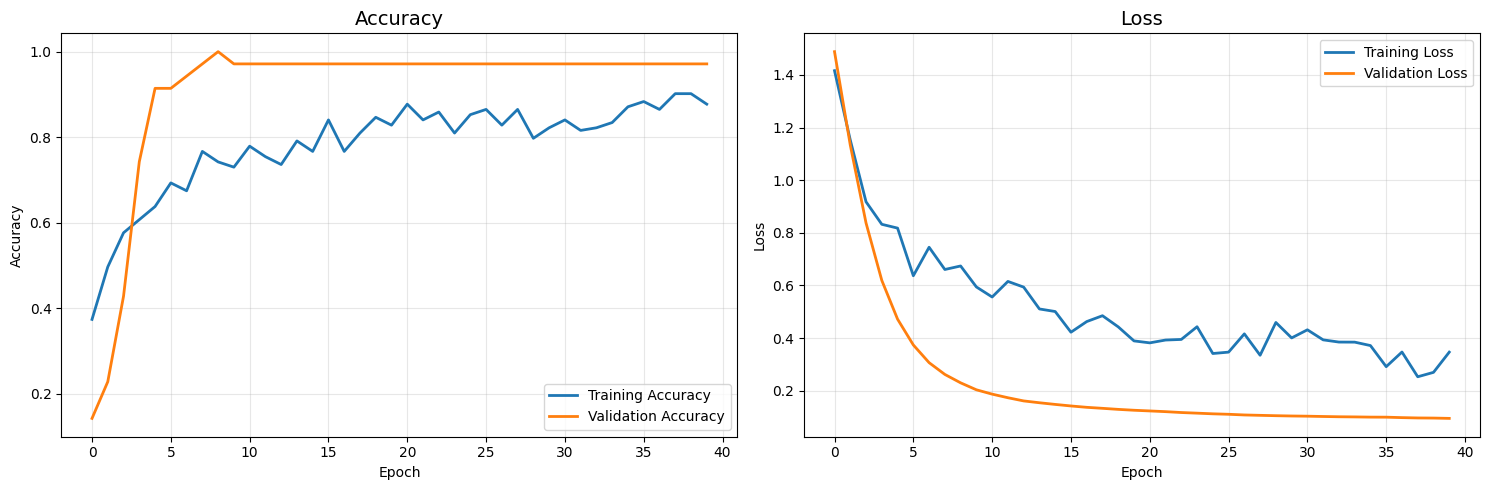

In [45]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.title('Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Matriz de confusión (modelo 8)

In [ ]:
y_true = np.concatenate([y for x, y in ds_test], axis=0)
y_true_classes = np.argmax(y_true, axis=1)
y_pred = modelo8.predict(ds_test)
y_pred_classes = np.argmax(y_pred, axis=1)

5/5 [==============================] - 2s 445ms/step


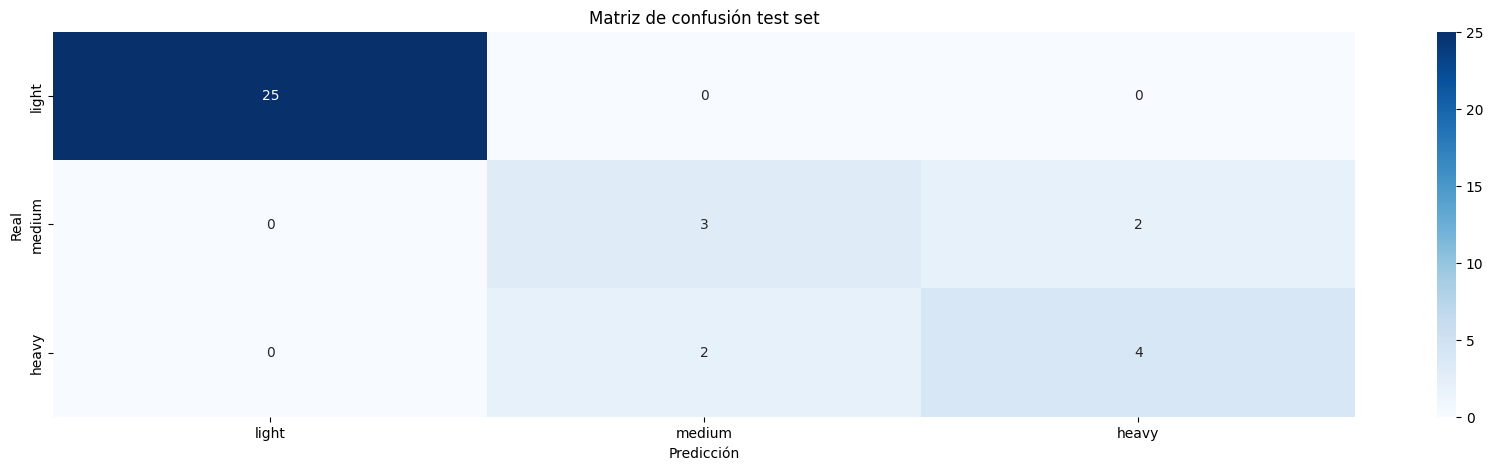

In [47]:
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(21, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
xticklabels=conf['clases'], 
yticklabels=conf['clases'])
plt.title(f'Matriz de confusión test set')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

In [49]:
print(classification_report(y_true_classes, y_pred_classes, target_names=conf['clases']))

              precision    recall  f1-score   support

       light       1.00      1.00      1.00        25
      medium       0.60      0.60      0.60         5
       heavy       0.67      0.67      0.67         6

    accuracy                           0.89        36
   macro avg       0.76      0.76      0.76        36
weighted avg       0.89      0.89      0.89        36



## 6. Conclusiones

#### Contexto y datos

El objetivo del proyecto fue desarrollar un sistema capaz de clasificar vídeos de autopistas en tres categorías de densidad de tráfico: **ligero, medio y pesado (congestionado)**.

* **Ingesta de Datos:** Se procesó un dataset de 254 vídeos brutos.
* **Preprocesamiento:** Se implementó un pipeline de extracción que convierte cada vídeo en una secuencia temporal de **15 frames** equiespaciados, redimensionados a 224x224 píxeles.
* **División de Datos:** Se realizó una partición estratificada para mantener el balance de clases y los splits fueron 70/15/15
  
---

#### Metodología de modelado

Se optó por una arquitectura híbrida **CNN-RNN**:

1. **Encoder (CNN):** Una red neuronal convolucional extrae características visuales de cada frame.
2. **Decoder (RNN):** Una red neuronal recurrente analiza la secuencia de esas características para entender el movimiento y el cambio temporal.
3. **Solución técnica:** Se implementó una capa personalizada `ManualTimeDistributedCNN` para solucionar un problema de compatibilidad técnica con TensorFlow/Windows.

---

#### Iteraciones experimentales y hallazgos clave

Se optó por una aproximación gradual de incremento de la complejidad, aislando variables en cada iteración.

* **Fase 1: selección del encoder (CNN)**
* **MobileNetV3 (baseline):** Mostró un buen aprendizaje inicial pero sufrió de *overfitting* severo.
* **MobileNetV2:** Al cambiar a esta arquitectura (congelada), el rendimiento se disparó a un **97% de precisión** en validación con una pérdida (loss) mínima de 0.11. Demostró ser el extractor de características ideal para este problema.
* **ResNet50 & EfficientNetV2:** Se probaron arquitecturas más densas/complejas. **Ambas fracasaron** tanto por alta latencia como por bajo rendimiento, posiblemente por el tamaño pequeño del dataset.
* **Intento de fine-tuning:** Se intentó descongelar MobileNetV2. Hubo una reducción del rendimiento, haciendo que los pesos pre-entrenados de ImageNet fueran ganadores.


* **Fase 2: optimización del decoder (RNN)**
* Una vez fijada **MobileNetV2 (sin fine tuning)** como la mejor extractora de características, se iteró sobre la parte temporal.
* Aumentar las neuronas LSTM a 64 provocó *overfitting*.
* Cambiar a **GRU** con un dropout alto (0.6) estabilizó el aprendizaje, logrando que la red generalizara mejor en lugar de memorizar.

---

#### El modelo final: MobileNetV2 + bidirectional GRU

El modelo ganador (el nº 8) fue una combinación de:

* **Encoder:** **MobileNetV2** (congelada).
* **Decoder:** **bidirectional GRU** (64 neuronas). La bidireccionalidad permite a la red analizar y comprender mejor el contexto temporal. 
* **Regularización:** **dropout del 50%**. Esto fuerza a la red a ser más estable y por tanto evitar overfitting.

---

#### Resultados

**Validation set:**

Fue el responsable de detener la experimentación en el punto óptimo.

* **Métricas:** Se logró una **accuracy de validación del 97.14%** y una **loss de 0.09**.
* **Análisis de retornos marginales:** Una pérdida tan baja indica que el modelo ya ha extraído prácticamente toda la información generalizable del dataset. Intentar reducir este valor mediante arquitecturas más complejas o entrenamientos más largos habría aportado ganancias insignificantes, disparando exponencialmente el riesgo de **overfitting**.

**Test set**

Al exponer el modelo al conjunto de **test**, se obtuvieron resultados sólidos: 

* **Accuracy: 89%**.
* **Desempeño en tráfico Ligero:** **perfecto (100%)**. El modelo no cometió ni un solo error al identificar tráfico fluido, lo cual es crítico para evitar falsas alarmas.
* **Confusión Medio/Pesado:** El 11% de error se concentra exclusivamente entre tráfico "medio" y "pesado". Dado el bajo número de muestras en estas clases, este margen es estadísticamente aceptable y atribuible a la subjetividad del etiquetado original más que a fallos del modelo.
  
---

#### Síntesis

La elección de **MobileNetV2 + Bi-GRU** ofrece el equilibrio perfecto entre precisión y eficiencia computacional. La decisión estratégica de detener la optimización al alcanzar un *validation loss* de 0.09 ha permitido entregar un modelo que sea preciso y también capaz de generalizar correctamente en entornos desconocidos, resolviendo el problema de clasificación con una fiabilidad satisfactoria.